# Global 모델링 Stage 1 — 42개 Feature의 Train 내부 비교

이 Notebook은 `baseline_42features`의 **Global Train**만 사용해 Logistic Regression과 XGBoost를 비교한다. 고정 Test Dataset은 읽거나 사용하지 않는다.

- CV: `StratifiedGroupKFold`, 5-fold, group=`SAMPID`, random_state=42
- 튜닝·전처리: 각 CV Train fold에서만 fit
- scoring 및 threshold: F1, 0.5
- `n_prior_periods`와 `sample_weight`: 사용하지 않음

수치와 그래프만 확인한다. 모델 선택·Feature 제거·결과 해석은 사람이 직접 한다.

In [21]:
import importlib
import os
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay

ROOT = Path(os.environ.get('KHUDA_PROJECT_ROOT', Path.cwd())).resolve()
while not (ROOT / 'code').is_dir():
    if ROOT.parent == ROOT:
        raise RuntimeError('KHUDA_PROJECT_ROOT에 저장소 루트를 지정하거나 저장소 안에서 Notebook을 실행하세요.')
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if 'code' in sys.modules and not hasattr(sys.modules['code'], '__path__'):
    del sys.modules['code']
# 외부에서 code/를 수정한 뒤에도 kernel을 재시작하지 않고 최신 모듈을 읽는다.
if 'code.model.first_stage' in sys.modules:
    importlib.reload(sys.modules['code.model.first_stage'])

from code.model.first_stage import (
    first_stage_summary,
    run_first_stage_modeling,
    save_first_stage_artifacts,
)
from code.model.train import load_model_config
from code.pipeline.saved_results import load_saved_global_train

EXPERIMENT = 'baseline_42features'
RESULT_ROOT = ROOT / 'data' / 'result' / EXPERIMENT
DATASET_PATH = RESULT_ROOT / 'datasets' / 'global_dataset.parquet'
SPLIT_PATH = RESULT_ROOT / 'splits' / 'split_ids.csv'
FEATURE_CONFIG = ROOT / 'code' / 'config' / 'features.yaml'
MODEL_CONFIG = ROOT / 'code' / 'config' / 'model_config.yaml'
OOF_OUTPUT_DIR = RESULT_ROOT / 'modeling' / 'stage_1'

for path in (DATASET_PATH, SPLIT_PATH, FEATURE_CONFIG, MODEL_CONFIG):
    if not path.exists():
        raise FileNotFoundError(f'필요한 Stage 1 입력 파일이 없습니다: {path}')

COLORS = {'logistic_regression': '#0066cc', 'xgboost': '#7a7a7a'}
LABELS = {'logistic_regression': 'Logistic Regression', 'xgboost': 'XGBoost'}
plt.rcParams.update({
    'figure.facecolor': '#f5f5f7', 'axes.facecolor': '#ffffff',
    'axes.edgecolor': '#e0e0e0', 'text.color': '#1d1d1f',
    'axes.labelcolor': '#1d1d1f', 'xtick.color': '#1d1d1f', 'ytick.color': '#1d1d1f',
})

In [6]:
# Test Dataset을 만들지 않고 고정 SAMPID split의 Train 행만 읽는다.
train_bundle = load_saved_global_train(DATASET_PATH, SPLIT_PATH, FEATURE_CONFIG)
model_config = load_model_config(MODEL_CONFIG)
official_models = model_config['official_comparison_models']

assert official_models == ['logistic_regression', 'xgboost']
assert train_bundle.X.shape[1] == 42
print(f'Experiment: {EXPERIMENT}')
print(f'Train Person-Periods: {len(train_bundle.y):,}')
print(f'Train unique SAMPID: {train_bundle.groups.nunique():,}')
print(f'Features used: {train_bundle.X.shape[1]}')
print(f'CV: StratifiedGroupKFold({model_config["split"]["cv_n_splits"]}), scoring={model_config["tuning"]["scoring"]}, threshold={model_config["tuning"]["threshold"]}')

Experiment: baseline_42features
Train Person-Periods: 11,925
Train unique SAMPID: 5,737
Features used: 42
CV: StratifiedGroupKFold(5), scoring=f1, threshold=0.5


In [7]:
# 재사용 함수가 GridSearchCV, Train-fold-only 전처리, 고정 파라미터 OOF 생성을 수행한다.
results = {}
for model_name in official_models:
    print(f'Running {LABELS[model_name]} ...')
    results[model_name] = run_first_stage_modeling(
        train_bundle,
        model_name=model_name,
        feature_config=FEATURE_CONFIG,
        model_config=MODEL_CONFIG,
        # Jupyter의 code 패키지 이름 충돌을 피하기 위해 탐색 worker는 현재 커널에서 순차 실행한다.
        n_jobs=1,
    )

comparison = first_stage_summary([results[name] for name in official_models])
display(comparison)

# best CV F1·fold별 F1·best parameter를 모델별로 확인한다.
display(pd.DataFrame([
    {
        'model': LABELS[name],
        'best_cv_f1': results[name].best_cv_f1,
        'fold_f1': results[name].fold_f1,
        'best_params': results[name].best_params,
    }
    for name in official_models
]))

Running Logistic Regression ...


/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ra

Running XGBoost ...


,model,n_features,best_cv_f1,cv_f1_mean,cv_f1_std,oof_precision,oof_recall,oof_f1,oof_roc_auc,best_params
0,logistic_regression,42,0.491064,0.491064,0.023322,0.420403,0.589859,0.490919,0.702318,"{'C': 1, 'class_weight': 'balanced', 'penalty'..."
1,xgboost,42,0.505448,0.505448,0.015153,0.412277,0.653081,0.505464,0.710588,"{'colsample_bytree': 1.0, 'learning_rate': 0.0..."


,model,best_cv_f1,fold_f1,best_params
0,Logistic Regression,0.491064,"(0.47459893048128343, 0.5153949129852744, 0.46...","{'C': 1, 'class_weight': 'balanced', 'penalty'..."
1,XGBoost,0.505448,"(0.4908747640025173, 0.525664811379097, 0.4941...","{'colsample_bytree': 1.0, 'learning_rate': 0.0..."


In [22]:
# Stage 2가 GridSearch를 다시 실행하지 않도록 OOF·요약표·최적 파라미터를 보관한다.
artifact_paths = save_first_stage_artifacts(
    [results[name] for name in official_models], OOF_OUTPUT_DIR
)
display(pd.DataFrame({'artifact': list(artifact_paths), 'path': [str(path) for path in artifact_paths.values()]}))

,artifact,path
0,logistic_regression_oof,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...
1,xgboost_oof,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...
2,summary,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...
3,best_params,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...
4,fold_f1,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...


## Train 내부 CV·OOF 시각화

아래 시각화는 비교 결과를 보여 줄 뿐, 어느 모델을 선택할지 결정하지 않는다.

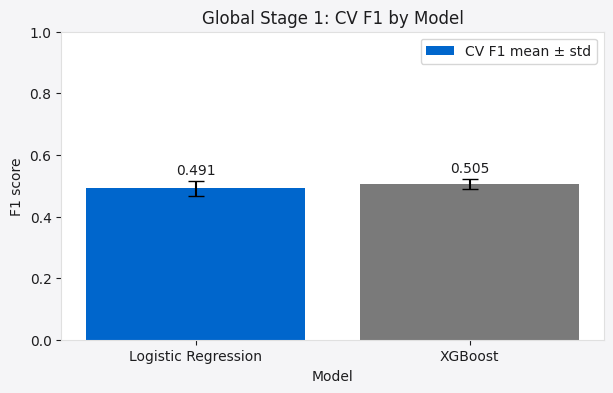

In [9]:
# 1. Logistic Regression vs XGBoost CV F1 (mean ± std)
plot_data = comparison.set_index('model').loc[official_models]
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    [LABELS[name] for name in official_models], plot_data['cv_f1_mean'],
    yerr=plot_data['cv_f1_std'], capsize=6,
    color=[COLORS[name] for name in official_models], label='CV F1 mean ± std',
)
ax.bar_label(bars, labels=[f'{value:.3f}' for value in plot_data['cv_f1_mean']], padding=3)
ax.set_title('Global Stage 1: CV F1 by Model')
ax.set_xlabel('Model')
ax.set_ylabel('F1 score')
ax.set_ylim(0, 1)
ax.legend()
plt.show()

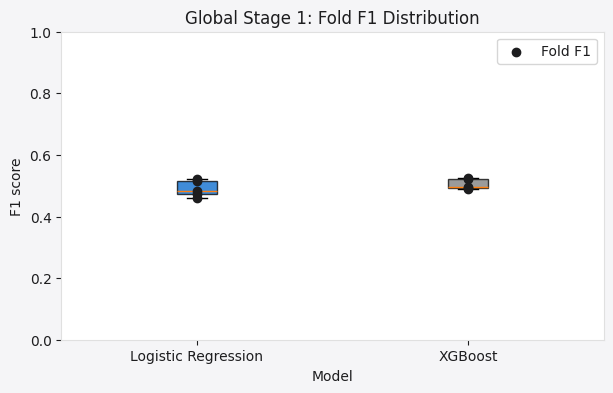

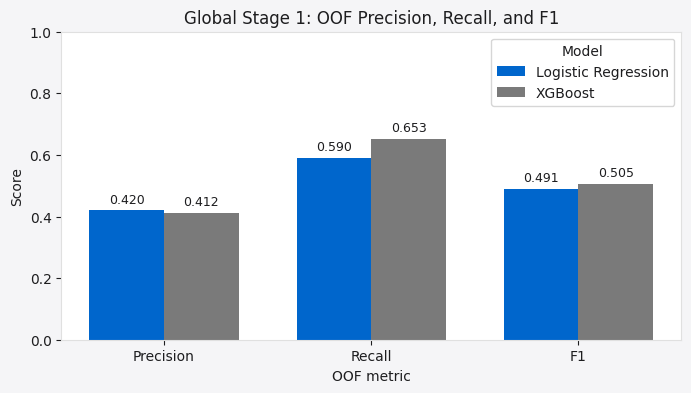

In [10]:
# 2. 모델별 fold F1 분포
fig, ax = plt.subplots(figsize=(7, 4))
fold_values = [results[name].fold_f1 for name in official_models]
box = ax.boxplot(fold_values, tick_labels=[LABELS[name] for name in official_models], patch_artist=True)
for patch, name in zip(box['boxes'], official_models):
    patch.set_facecolor(COLORS[name])
    patch.set_alpha(0.75)
for index, values in enumerate(fold_values, start=1):
    ax.scatter(np.full(len(values), index), values, color='#1d1d1f', zorder=3, label='Fold F1' if index == 1 else None)
ax.set_title('Global Stage 1: Fold F1 Distribution')
ax.set_xlabel('Model')
ax.set_ylabel('F1 score')
ax.set_ylim(0, 1)
ax.legend()
plt.show()

# 3. OOF Precision / Recall / F1 비교
metric_columns = ['oof_precision', 'oof_recall', 'oof_f1']
metric_labels = ['Precision', 'Recall', 'F1']
x = np.arange(len(metric_columns))
width = 0.36
fig, ax = plt.subplots(figsize=(8, 4))
for index, model_name in enumerate(official_models):
    values = plot_data.loc[model_name, metric_columns].to_numpy(dtype=float)
    bars = ax.bar(x + (index - 0.5) * width, values, width, label=LABELS[model_name], color=COLORS[model_name])
    ax.bar_label(bars, labels=[f'{value:.3f}' for value in values], padding=3, fontsize=9)
ax.set_title('Global Stage 1: OOF Precision, Recall, and F1')
ax.set_xlabel('OOF metric')
ax.set_ylabel('Score')
ax.set_xticks(x, metric_labels)
ax.set_ylim(0, 1)
ax.legend(title='Model')
plt.show()

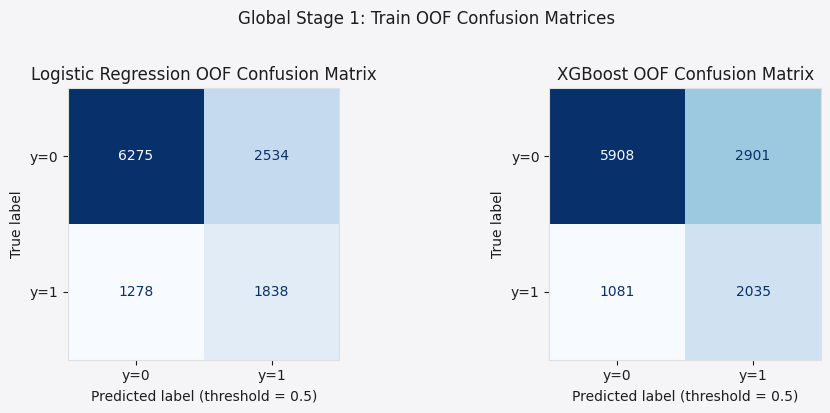

In [11]:
# 4-5. 모델별 OOF Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, model_name in zip(axes, official_models):
    matrix = np.asarray(results[model_name].oof_metrics['confusion_matrix'])
    ConfusionMatrixDisplay(matrix, display_labels=['y=0', 'y=1']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{LABELS[model_name]} OOF Confusion Matrix')
    ax.set_xlabel('Predicted label (threshold = 0.5)')
    ax.set_ylabel('True label')
fig.suptitle('Global Stage 1: Train OOF Confusion Matrices', y=1.02)
fig.tight_layout()
plt.show()

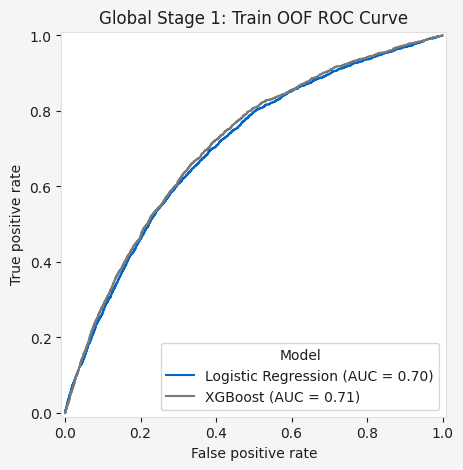

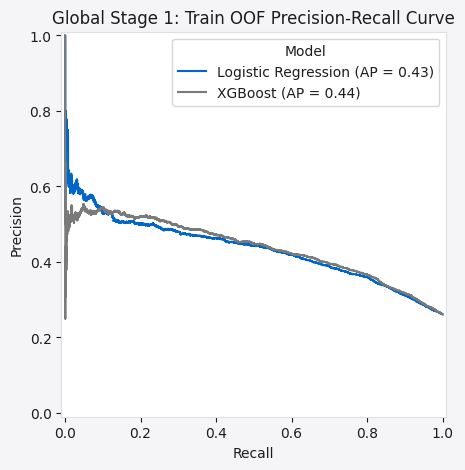

In [12]:
# 6. 두 모델의 OOF ROC Curve
fig, ax = plt.subplots(figsize=(6, 5))
for model_name in official_models:
    prediction = results[model_name].oof_predictions
    roc_display = RocCurveDisplay.from_predictions(
        prediction['y_true'], prediction['y_probability'],
        name=LABELS[model_name], ax=ax,
    )
    roc_display.line_.set_color(COLORS[model_name])
ax.set_title('Global Stage 1: Train OOF ROC Curve')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.legend(title='Model')
plt.show()

# 7. 두 모델의 OOF Precision-Recall Curve
fig, ax = plt.subplots(figsize=(6, 5))
for model_name in official_models:
    prediction = results[model_name].oof_predictions
    pr_display = PrecisionRecallDisplay.from_predictions(
        prediction['y_true'], prediction['y_probability'],
        name=LABELS[model_name], ax=ax,
    )
    pr_display.line_.set_color(COLORS[model_name])
ax.set_title('Global Stage 1: Train OOF Precision-Recall Curve')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(title='Model')
plt.show()

In [13]:
# Stage 1 비교표: 수치 확인용이며 자동 선택에는 사용하지 않는다.
display(comparison[[
    'model', 'n_features', 'cv_f1_mean', 'cv_f1_std',
    'oof_precision', 'oof_recall', 'oof_f1', 'oof_roc_auc', 'best_params',
]])

,model,n_features,cv_f1_mean,cv_f1_std,oof_precision,oof_recall,oof_f1,oof_roc_auc,best_params
0,logistic_regression,42,0.491064,0.023322,0.420403,0.589859,0.490919,0.702318,"{'C': 1, 'class_weight': 'balanced', 'penalty'..."
1,xgboost,42,0.505448,0.015153,0.412277,0.653081,0.505464,0.710588,"{'colsample_bytree': 1.0, 'learning_rate': 0.0..."


## 다음 단계

이 Notebook은 모델을 자동 선택하거나 Feature를 제거하지 않는다. Stage 2로 진행할지와 어떤 Feature 분석 결과를 사용할지는 실행자가 직접 판단·기록한다.